In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [6]:
df = pd.read_csv("Mall_Customers.csv")

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [12]:
X = df.iloc[:, [3,4]].values

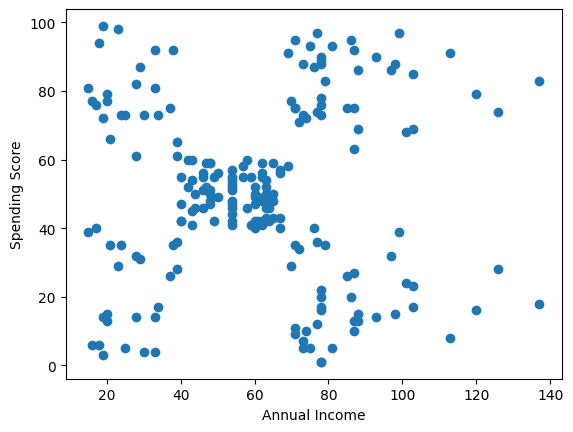

In [13]:
plt.scatter(X[:,0], X[:,1])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [21]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

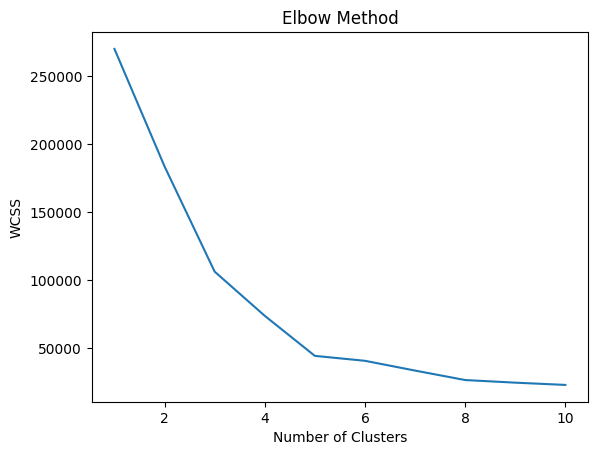

In [22]:
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [19]:
len(wcss)

20

In [24]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

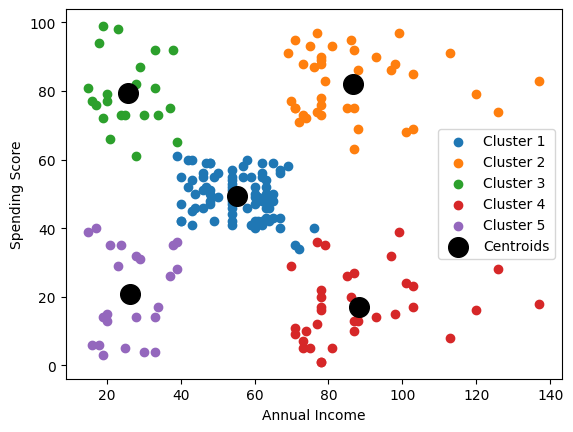

In [25]:
plt.scatter(X[y_kmeans==0,0], X[y_kmeans==0,1], label="Cluster 1")
plt.scatter(X[y_kmeans==1,0], X[y_kmeans==1,1], label="Cluster 2")
plt.scatter(X[y_kmeans==2,0], X[y_kmeans==2,1], label="Cluster 3")
plt.scatter(X[y_kmeans==3,0], X[y_kmeans==3,1], label="Cluster 4")
plt.scatter(X[y_kmeans==4,0], X[y_kmeans==4,1], label="Cluster 5")

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    c='black',
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

In [26]:
df["Cluster"] = y_kmeans


In [27]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [29]:
df.to_csv("Clustered_Customers.csv", index=False)

In [30]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [31]:
df["Cluster"].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [32]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [33]:
plt.savefig("elbow_method.png")

<Figure size 640x480 with 0 Axes>

In [34]:
plt.savefig("clusters.png")

<Figure size 640x480 with 0 Axes>